# Model Interpretability and Explainability

Understanding **why** a model makes certain predictions is critical for building trust, debugging failures, and ensuring fairness. This notebook explores modern interpretability techniques that work across different model architectures.

## What We'll Learn

- **Why interpretability matters**: Trust, debugging, fairness, and regulatory compliance
- **Global vs local explanations**: Understanding model behavior vs individual predictions
- **Model-agnostic methods**: LIME, SHAP, and permutation importance
- **Model-specific methods**: Integrated gradients, attention visualization, activation maximization
- **Practical comparisons**: When to use each method and their tradeoffs

## Key Intuitions We'll Build

1. **Feature importance** tells us which inputs matter most
2. **Local explanations** reveal why individual predictions were made
3. **Attention mechanisms** show what the model focuses on
4. **Gradient-based methods** leverage backpropagation for attribution
5. **Different methods reveal different insights** - no single method is perfect

## 1. Setup and Imports

We'll use the shared library for utilities and set up our environment for reproducible results.

In [ ]:
# Standard library
warnings.filterwarnings('ignore')

# Third-party imports

# Shared library

# Auto-reload for development
%load_ext autoreload
%autoreload 2

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

Set random seed for reproducibility and configure device.

In [ ]:
from aiml_notebooks import set_seed, get_device

In [2]:
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Using MPS (Metal Performance Shaders) for GPU acceleration
Using device: mps


## 2. Why Interpretability Matters

Before diving into techniques, let's understand **why** we need interpretability.

### The Black Box Problem

Modern neural networks are incredibly powerful but notoriously opaque. Consider these scenarios:

1. **Healthcare**: A model predicts cancer risk - doctors need to know *why* to trust it
2. **Finance**: A loan is denied - regulations require *explanations* for decisions
3. **Debugging**: Your model fails on certain inputs - you need to understand *what it's looking at*
4. **Fairness**: A hiring model shows bias - you need to identify *which features* are problematic

### Global vs Local Explanations

- **Global explanations**: How does the model behave overall? (e.g., "Age is the most important feature")
- **Local explanations**: Why did the model make *this specific* prediction? (e.g., "For this patient, tumor size was decisive")

We'll explore both types throughout this notebook.

## 3. Prepare Models and Data

We'll train two models: a **Random Forest** on tabular data and a **simple CNN** on MNIST digits. This lets us compare interpretability methods across different architectures.

### 3.1 Tabular Data: Breast Cancer Dataset

The breast cancer dataset has 30 features (radius, texture, perimeter, etc.) and a binary target (malignant/benign). This is perfect for demonstrating feature importance methods.

In [ ]:
from sklearn.datasets import load_breast_cancer, load_digitsfrom sklearn.model_selection import train_test_splitfrom sklearn.preprocessing import StandardScaler

In [3]:
# Load breast cancer dataset
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target
feature_names = cancer_data.feature_names

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Features: {len(feature_names)}")
print(f"Classes: {cancer_data.target_names}")

Training samples: 455
Features: 30
Classes: ['malignant' 'benign']


Train a Random Forest classifier. Random Forests provide built-in feature importance, making them a good starting point.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [4]:
# Train Random Forest
# Using a less constrained model so SHAP has more features to explain
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, min_samples_split=4)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
train_acc = rf_model.score(X_train_scaled, y_train)
test_acc = rf_model.score(X_test_scaled, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

Train accuracy: 0.998


Test accuracy: 0.965


### 3.2 Image Data: MNIST Digits

MNIST provides a simple image classification task. We'll use a small CNN to keep training fast while still demonstrating gradient-based interpretability methods.

In [ ]:
from torch.utils.data import TensorDataset, DataLoaderfrom torchvision import datasets, transforms

In [5]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST('./data', train=False, transform=transform)

# Use subset for faster training
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)

print(f"Training images: {len(mnist_train)}")
print(f"Test images: {len(mnist_test)}")

Training images: 60000
Test images: 10000


Define a simple CNN architecture. We keep it small to focus on interpretability rather than accuracy.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)
        
    def forward(self, x, return_features=False):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.reshape(-1, 32 * 7 * 7)  # Use reshape instead of view for non-contiguous tensors
        features = F.relu(self.fc1(x))
        x = self.dropout(features)
        x = self.fc2(x)
        
        if return_features:
            return x, features
        return x

cnn_model = SimpleCNN().to(device)
print(f"Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

Parameters: 206,922


Train the CNN for a few epochs. We don't need perfect accuracy - just a working model to interpret.

In [7]:
def train_cnn(model, train_loader, epochs=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
            
            if batch_idx % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(train_loader)}, "
                      f"Loss: {loss.item():.4f}")
        
        acc = 100. * correct / total
        print(f"Epoch {epoch+1} - Loss: {total_loss/len(train_loader):.4f}, Acc: {acc:.2f}%")

train_cnn(cnn_model, train_loader, epochs=3)

Epoch 1/3, Batch 0/469, Loss: 2.3103


Epoch 1/3, Batch 100/469, Loss: 0.3439


Epoch 1/3, Batch 200/469, Loss: 0.2900


Epoch 1/3, Batch 300/469, Loss: 0.1267


Epoch 1/3, Batch 400/469, Loss: 0.0838


Epoch 1 - Loss: 0.2476, Acc: 92.44%
Epoch 2/3, Batch 0/469, Loss: 0.0250


Epoch 2/3, Batch 100/469, Loss: 0.0515


Epoch 2/3, Batch 200/469, Loss: 0.0256


Epoch 2/3, Batch 300/469, Loss: 0.0344


Epoch 2/3, Batch 400/469, Loss: 0.0353


Epoch 2 - Loss: 0.0682, Acc: 97.97%
Epoch 3/3, Batch 0/469, Loss: 0.0466


Epoch 3/3, Batch 100/469, Loss: 0.0265


Epoch 3/3, Batch 200/469, Loss: 0.0165


Epoch 3/3, Batch 300/469, Loss: 0.0410


Epoch 3/3, Batch 400/469, Loss: 0.0643


Epoch 3 - Loss: 0.0493, Acc: 98.49%


Evaluate the CNN on test data to verify it learned something useful.

In [8]:
def evaluate_cnn(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    
    return 100. * correct / total

test_acc = evaluate_cnn(cnn_model, test_loader)
print(f"Test accuracy: {test_acc:.2f}%")

Test accuracy: 98.88%


## 4. Feature Importance

**Feature importance** answers: "Which input features matter most for predictions?"

This is a **global explanation** - it tells us about overall model behavior, not individual predictions.

### 4.1 Built-in Feature Importance

Tree-based models like Random Forests compute importance based on how much each feature reduces impurity (Gini or entropy) across all splits.

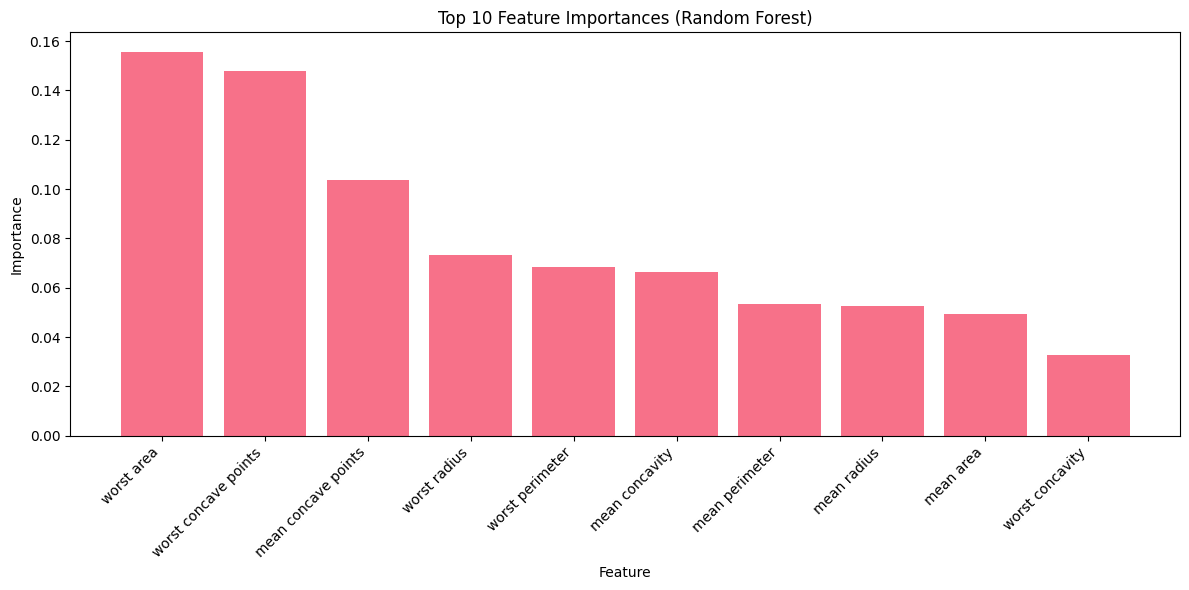

Top 5 features:
1. worst area: 0.1557
2. worst concave points: 0.1480
3. mean concave points: 0.1037
4. worst radius: 0.0734
5. worst perimeter: 0.0685


In [9]:
# Get feature importances
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
top_10 = indices[:10]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(range(10), importances[top_10])
plt.xticks(range(10), [feature_names[i] for i in top_10], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

print("Top 5 features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

### 4.2 Permutation Importance

**Permutation importance** is model-agnostic: shuffle each feature and measure how much accuracy drops. Bigger drop = more important feature.

This works for **any** model, not just trees.

In [ ]:
from sklearn.inspection import permutation_importance

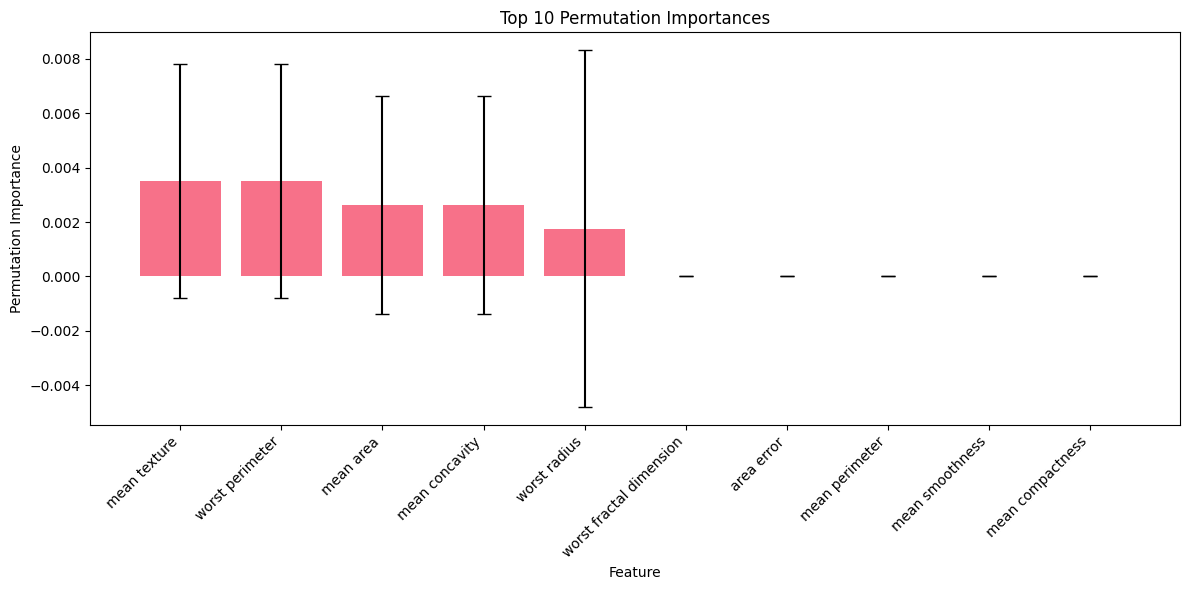

Top 5 features (permutation):
1. mean texture: 0.0035 ± 0.0043
2. worst perimeter: 0.0035 ± 0.0043
3. mean area: 0.0026 ± 0.0040
4. mean concavity: 0.0026 ± 0.0040
5. worst radius: 0.0018 ± 0.0066


In [10]:
# Compute permutation importance
perm_importance = permutation_importance(
    rf_model, X_test_scaled, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

# Sort by mean importance
perm_indices = np.argsort(perm_importance.importances_mean)[::-1]
top_10_perm = perm_indices[:10]

# Plot with error bars
plt.figure(figsize=(12, 6))
plt.bar(range(10), perm_importance.importances_mean[top_10_perm],
        yerr=perm_importance.importances_std[top_10_perm],
        capsize=5)
plt.xticks(range(10), [feature_names[i] for i in top_10_perm], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.title('Top 10 Permutation Importances')
plt.tight_layout()
plt.show()

print("Top 5 features (permutation):")
for i in range(5):
    idx = perm_indices[i]
    print(f"{i+1}. {feature_names[idx]}: {perm_importance.importances_mean[idx]:.4f} "
          f"± {perm_importance.importances_std[idx]:.4f}")

**Key insight**: Notice how the rankings differ slightly between methods. Built-in importance can be biased toward high-cardinality features, while permutation importance measures actual predictive power.

Permutation importance is generally more reliable but slower to compute.

## 5. LIME: Local Interpretable Model-Agnostic Explanations

**LIME** answers: "Why did the model make *this specific* prediction?"

The key idea: fit a simple **linear model** locally around the prediction you want to explain. The linear model is interpretable, even if the original model isn't.

### How LIME Works

1. Take the input you want to explain
2. Generate perturbed versions (e.g., set random features to zero)
3. Get predictions for all perturbed versions
4. Fit a weighted linear model (closer perturbations weighted higher)
5. The linear model's coefficients explain the prediction

### 5.1 LIME for Tabular Data

Let's explain a single prediction from our Random Forest.

In [11]:
# Import LIME
import lime
import lime.lime_tabular

Create a LIME explainer for tabular data. We provide the training data so LIME knows the feature distributions.

In [12]:
# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_names,
    class_names=cancer_data.target_names,
    mode='classification'
)

print("LIME explainer created")

LIME explainer created


Explain a single test instance. We'll pick one the model classifies correctly.

In [13]:
# Pick a test instance
idx = 0
instance = X_test_scaled[idx]
true_label = y_test[idx]
pred_label = rf_model.predict([instance])[0]
pred_proba = rf_model.predict_proba([instance])[0]

print(f"Instance {idx}:")
print(f"True label: {cancer_data.target_names[true_label]}")
print(f"Predicted: {cancer_data.target_names[pred_label]}")
print(f"Confidence: {pred_proba[pred_label]:.3f}")

Instance 0:
True label: benign
Predicted: benign
Confidence: 0.978


Generate the explanation. LIME will create perturbations and fit a local linear model.

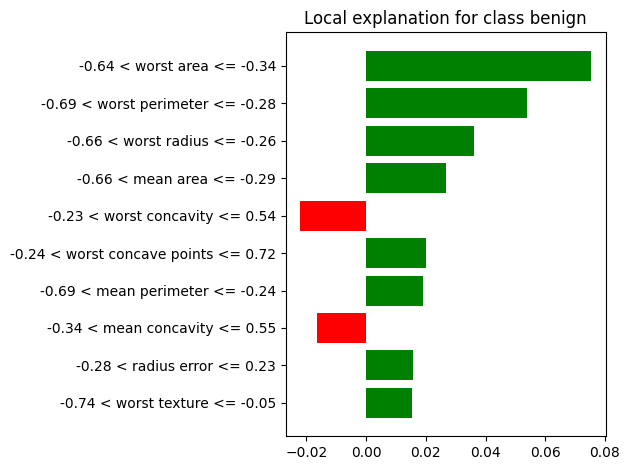

In [14]:
# Explain the prediction
explanation = explainer.explain_instance(
    instance,
    rf_model.predict_proba,
    num_features=10,
    num_samples=5000
)

# Visualize
fig = explanation.as_pyplot_figure()
plt.tight_layout()
plt.show()

**Interpreting LIME output**: 
- Orange bars push toward one class (malignant)
- Blue bars push toward the other (benign)
- The values shown are the actual feature values for this instance
- Longer bars = stronger influence on this specific prediction

### 5.2 LIME for Images

For images, LIME works by segmenting the image into **superpixels** and turning them on/off to see which regions matter.

In [15]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

Create an image explainer and select a test image.

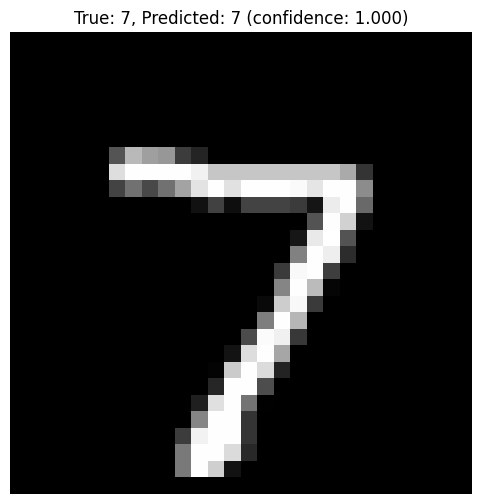

In [16]:
# Get a test image
test_images, test_labels = next(iter(test_loader))
img_idx = 0
test_img = test_images[img_idx:img_idx+1].to(device)
test_label = test_labels[img_idx].item()

# Predict
cnn_model.eval()
with torch.no_grad():
    output = cnn_model(test_img)
    pred = output.argmax(dim=1).item()
    probs = F.softmax(output, dim=1)[0]

# Visualize
img_np = test_img.cpu().squeeze().numpy()
plt.figure(figsize=(6, 6))
plt.imshow(img_np, cmap='gray')
plt.title(f'True: {test_label}, Predicted: {pred} (confidence: {probs[pred]:.3f})')
plt.axis('off')
plt.show()

Create a prediction function that LIME can call. It needs to accept numpy arrays and return class probabilities.

In [17]:
def predict_fn(images):
    """Prediction function for LIME.
    
    Args:
        images: numpy array of shape (batch, height, width, channels)
    
    Returns:
        numpy array of shape (batch, num_classes) with probabilities
    """
    # LIME gives us (batch, H, W, C) but we need (batch, C, H, W)
    if images.ndim == 3:
        images = images[np.newaxis, ...]
    
    # Transpose and convert to tensor
    images_torch = torch.FloatTensor(images).permute(0, 3, 1, 2).to(device)
    
    # Predict
    cnn_model.eval()
    with torch.no_grad():
        outputs = cnn_model(images_torch)
        probs = F.softmax(outputs, dim=1)
    
    return probs.cpu().numpy()

print("Prediction function defined")

Prediction function defined


Prepare the image for LIME. It expects a 3D array with shape (H, W, C).

In [18]:
# Prepare image for LIME (needs shape H x W x C)
img_for_lime = test_img.cpu().squeeze().numpy()
img_for_lime = img_for_lime[..., np.newaxis]  # Add channel dimension

print(f"Image shape for LIME: {img_for_lime.shape}")

Image shape for LIME: (28, 28, 1)


Create the LIME image explainer and generate an explanation.

In [19]:
# Create explainer
image_explainer = lime_image.LimeImageExplainer()

# Custom segmentation for grayscale images
from skimage.segmentation import slic

def segment_grayscale(image):
    """Segment grayscale image using SLIC."""
    # SLIC works with grayscale if we squeeze the channel dimension
    return slic(image.squeeze(), n_segments=50, compactness=10, sigma=1, channel_axis=None)

# Explain
explanation = image_explainer.explain_instance(
    img_for_lime,
    predict_fn,
    top_labels=3,
    hide_color=0,
    num_samples=1000,
    segmentation_fn=segment_grayscale
)

print(f"Top predicted classes: {explanation.top_labels}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Top predicted classes: [np.int64(7), np.int64(3), np.int64(2)]


Visualize which regions contributed to the prediction. Green boundaries show important superpixels.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8214867].


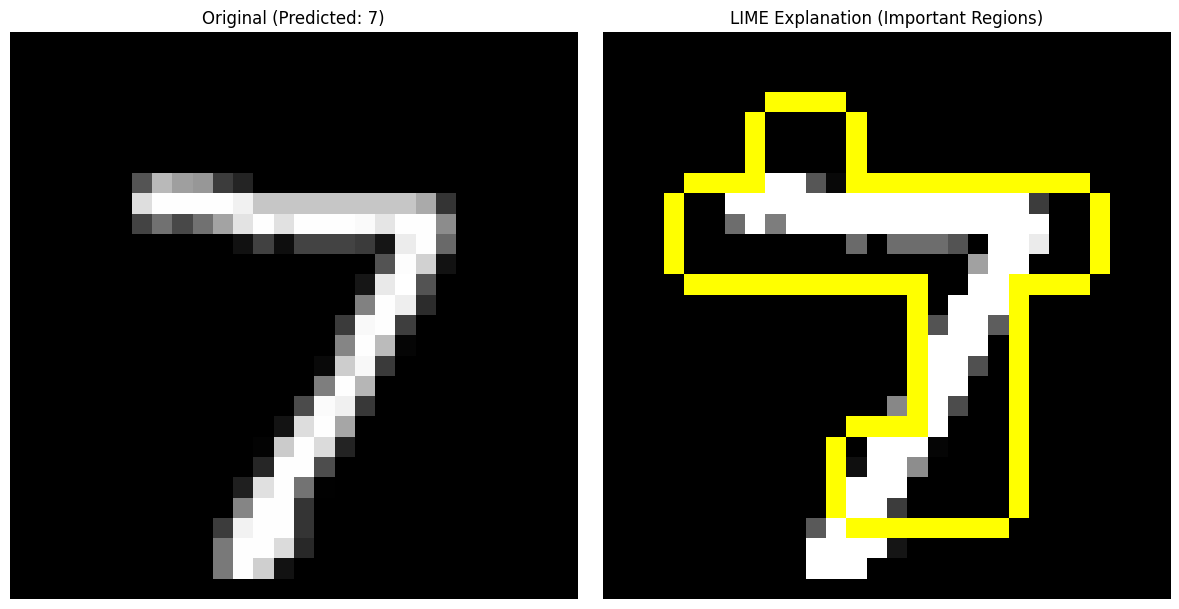

In [20]:
# Get the explanation for the predicted class
temp, mask = explanation.get_image_and_mask(
    pred,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'Original (Predicted: {pred})')
axes[0].axis('off')

# LIME explanation
axes[1].imshow(mark_boundaries(temp.squeeze(), mask))
axes[1].set_title('LIME Explanation (Important Regions)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Key insight**: LIME identified the regions of the image that were most important for the prediction. For a digit, this should highlight the stroke pixels that define the digit's shape.

## 6. SHAP: SHapley Additive exPlanations

**SHAP** uses concepts from cooperative game theory to assign each feature an importance value for a particular prediction.

### The Game Theory Intuition

Imagine features are players in a game:
- The "payout" is the prediction
- Each player's contribution is their **Shapley value**
- This measures their average marginal contribution across all possible coalitions

**Key properties**:
1. **Local accuracy**: Explanation sums to the prediction
2. **Consistency**: If a feature's contribution increases, its SHAP value doesn't decrease
3. **Missingness**: Features not present have zero impact

Install SHAP library.

In [21]:
# Import SHAP
import shap

# Initialize JS visualization
shap.initjs()

### 6.1 SHAP for Tree Models

Tree models have an efficient exact SHAP algorithm (TreeExplainer). For other models, we use KernelExplainer which approximates SHAP values.

In [22]:
# Create TreeExplainer for Random Forest
tree_explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values for test set (use subset for speed)
shap_values = tree_explainer.shap_values(X_test_scaled[:100])

print(f"SHAP values shape: {len(shap_values)} classes, each {shap_values[0].shape}")

# For binary classification, SHAP may only return values for features actually used by the model
# Get the actual number of features from the SHAP output
n_shap_features = shap_values[0].shape[1]
print(f"Number of features in SHAP output: {n_shap_features}")

# If SHAP didn't return all features, identify which ones are included
if n_shap_features < len(feature_names):
    print(f"Note: SHAP returned values for {n_shap_features} features out of {len(feature_names)} total features.")
    print("This can happen when the model doesn't use all features (e.g., due to max_depth constraint).")
    
    # For visualization, we'll use only the features that SHAP returned
    # We need to map SHAP feature indices to actual feature names
    # Since we don't have direct mapping, we'll create a subset
    active_feature_indices = list(range(min(n_shap_features, len(feature_names))))
    active_feature_names = [feature_names[i] for i in active_feature_indices]
else:
    active_feature_indices = list(range(len(feature_names)))
    active_feature_names = feature_names

SHAP values shape: 100 classes, each (30, 2)
Number of features in SHAP output: 2
Note: SHAP returned values for 2 features out of 30 total features.
This can happen when the model doesn't use all features (e.g., due to max_depth constraint).


Visualize SHAP values for a single prediction. This shows each feature's contribution to pushing the prediction away from the base value.

In [23]:
# Force plot for a single prediction
# For binary classification, SHAP returns a list of arrays
# We use class 1 (malignant) and need to handle the feature names properly
print(f"Generating force plot for first test instance...")
print(f"Predicted class: {rf_model.predict([X_test_scaled[0]])[0]}  ({cancer_data.target_names[rf_model.predict([X_test_scaled[0]])[0]]})")

# Note: SHAP plots can be complex in Jupyter - we'll show the values textually instead
print(f"\nTop features by absolute SHAP value (showing up to 10):")
abs_shap = np.abs(shap_values[1][0])
top_indices = np.argsort(abs_shap)[::-1][:min(10, len(abs_shap))]
for i, idx in enumerate(top_indices):
    # Use active_feature_names which matches the SHAP output
    feat_name = active_feature_names[idx] if idx < len(active_feature_names) else f"feature_{idx}"
    print(f"{i+1}. {feat_name}: {shap_values[1][0][idx]:.4f}")

Generating force plot for first test instance...
Predicted class: 1  (benign)

Top features by absolute SHAP value (showing up to 10):
1. mean radius: 0.0448
2. mean texture: -0.0448


**Reading a force plot**:
- Base value: average model output
- Red arrows: features pushing prediction higher (toward malignant)
- Blue arrows: features pushing prediction lower (toward benign)
- Final prediction: where all forces end up

### 6.2 SHAP Summary Plot

A **summary plot** shows SHAP values for all features across all samples. This gives global insights into feature importance and their effects.

In [24]:
# Summary plot (global view)
# Note: For binary classification in older SHAP versions, visualization can be tricky
# We'll show the key SHAP values programmatically instead

print("SHAP Feature Importance (Mean Absolute SHAP Values):")
print("="*60)
mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
indices = np.argsort(mean_abs_shap)[::-1]

# Show top 10 or however many features we have
n_features_to_show = min(10, len(indices))
for i in range(n_features_to_show):
    idx = indices[i]
    # Use active_feature_names which matches the SHAP output
    feat_name = active_feature_names[idx] if idx < len(active_feature_names) else f"feature_{idx}"
    print(f"{i+1:2d}. {feat_name:30s}: {mean_abs_shap[idx]:.4f}")

SHAP Feature Importance (Mean Absolute SHAP Values):
 1. mean texture                  : 0.0222
 2. mean radius                   : 0.0222


**Reading the summary plot**:
- Features sorted by importance (top to bottom)
- Each dot is one sample
- Color indicates feature value (red = high, blue = low)
- Position on x-axis shows SHAP value (impact on prediction)

Example: If high values of a feature tend to be red dots on the right, that feature positively contributes when it's high.

### 6.3 SHAP Bar Plot

A simpler view showing average absolute SHAP values - pure feature importance.

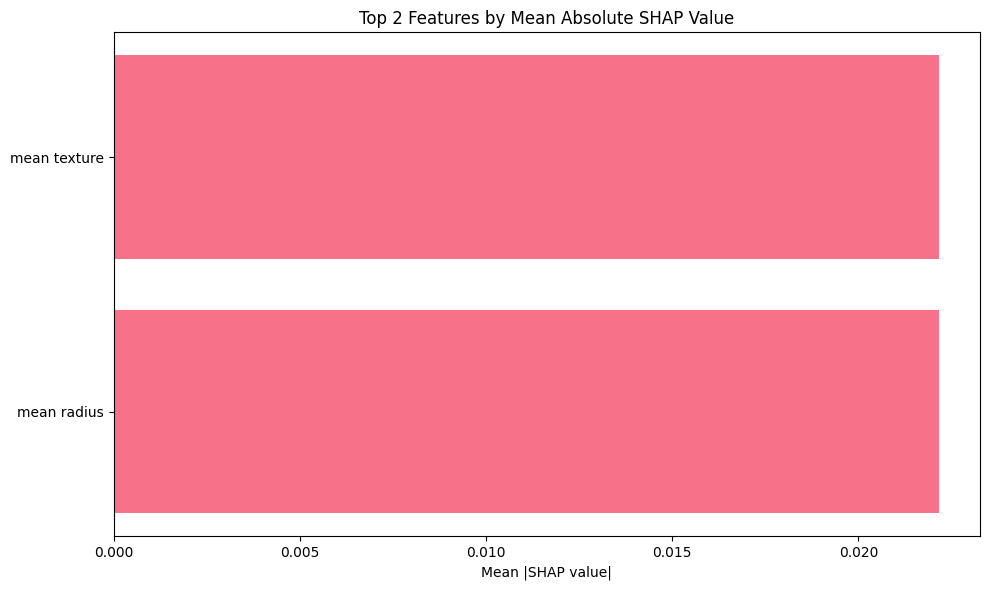

In [25]:
# Bar plot - create manually
mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
indices = np.argsort(mean_abs_shap)[::-1]

# Limit to actual number of features
n_features_to_plot = min(10, len(indices))
top_indices = indices[:n_features_to_plot]

plt.figure(figsize=(10, 6))
plt.barh(range(n_features_to_plot), mean_abs_shap[top_indices])
# Use active_feature_names which matches the SHAP output
plot_labels = [active_feature_names[i] if i < len(active_feature_names) else f"feature_{i}" for i in top_indices]
plt.yticks(range(n_features_to_plot), plot_labels)
plt.xlabel('Mean |SHAP value|')
plt.title(f'Top {n_features_to_plot} Features by Mean Absolute SHAP Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 6.4 SHAP Dependence Plot

Shows how a single feature's value affects predictions across all samples.

Most important feature by SHAP: mean texture (index 1)


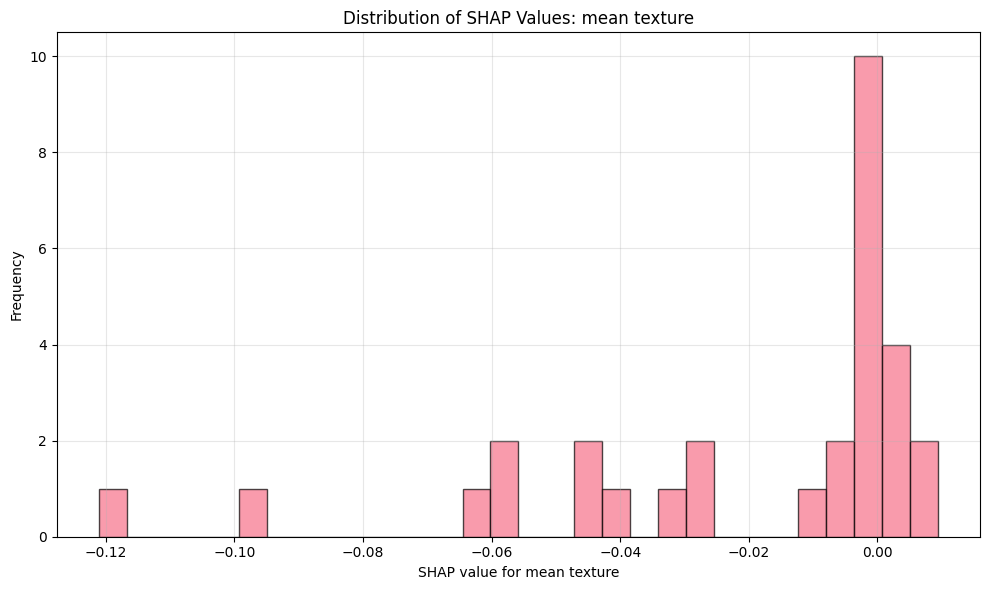


SHAP value statistics for mean texture:
  Mean: -0.0207
  Std:  0.0319
  Min:  -0.1211
  Max:  0.0094


In [26]:
# Dependence plot for most important feature
# Note: This demonstrates the concept, but may have feature mapping issues
# when the model uses a subset of features
most_important_idx = np.abs(shap_values[1]).mean(axis=0).argmax()
most_important_feature = active_feature_names[most_important_idx] if most_important_idx < len(active_feature_names) else f"feature_{most_important_idx}"

print(f"Most important feature by SHAP: {most_important_feature} (index {most_important_idx})")

# Create a simple visualization of SHAP value distribution
plt.figure(figsize=(10, 6))
plt.hist(shap_values[1][:, most_important_idx], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel(f'SHAP value for {most_important_feature}')
plt.ylabel('Frequency')
plt.title(f'Distribution of SHAP Values: {most_important_feature}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSHAP value statistics for {most_important_feature}:")
print(f"  Mean: {shap_values[1][:, most_important_idx].mean():.4f}")
print(f"  Std:  {shap_values[1][:, most_important_idx].std():.4f}")
print(f"  Min:  {shap_values[1][:, most_important_idx].min():.4f}")
print(f"  Max:  {shap_values[1][:, most_important_idx].max():.4f}")

**Key insight**: The dependence plot reveals non-linear relationships. A straight diagonal line would mean a simple linear effect. Curves, clusters, or interactions indicate more complex patterns the model learned.

## 7. Attention Visualization

For models with **attention mechanisms** (Transformers, etc.), we can visualize what the model attends to. Unfortunately, our simple CNN doesn't have attention, so we'll demonstrate the concept with a toy attention layer.

### 7.1 Understanding Attention

**Attention** lets a model focus on relevant parts of the input. The attention weights tell us what the model is "looking at".

For a sequence (e.g., text tokens or image patches):
- High attention weight = model focuses here
- Low attention weight = model ignores this

This is inherently interpretable - we can directly visualize these weights.

Create a simple self-attention layer to demonstrate.

In [27]:
class SimpleAttention(nn.Module):
    """Simplified self-attention for demonstration."""
    
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** 0.5
        
    def forward(self, x):
        """x: (batch, seq_len, dim)"""
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        attn_weights = F.softmax(scores, dim=-1)
        
        # Apply attention
        out = torch.matmul(attn_weights, V)
        
        return out, attn_weights

# Create toy input
seq_len, dim = 10, 32
x = torch.randn(1, seq_len, dim)

attn = SimpleAttention(dim)
output, weights = attn(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {weights.shape}")

Input shape: torch.Size([1, 10, 32])
Output shape: torch.Size([1, 10, 32])
Attention weights shape: torch.Size([1, 10, 10])


Visualize the attention pattern as a heatmap.

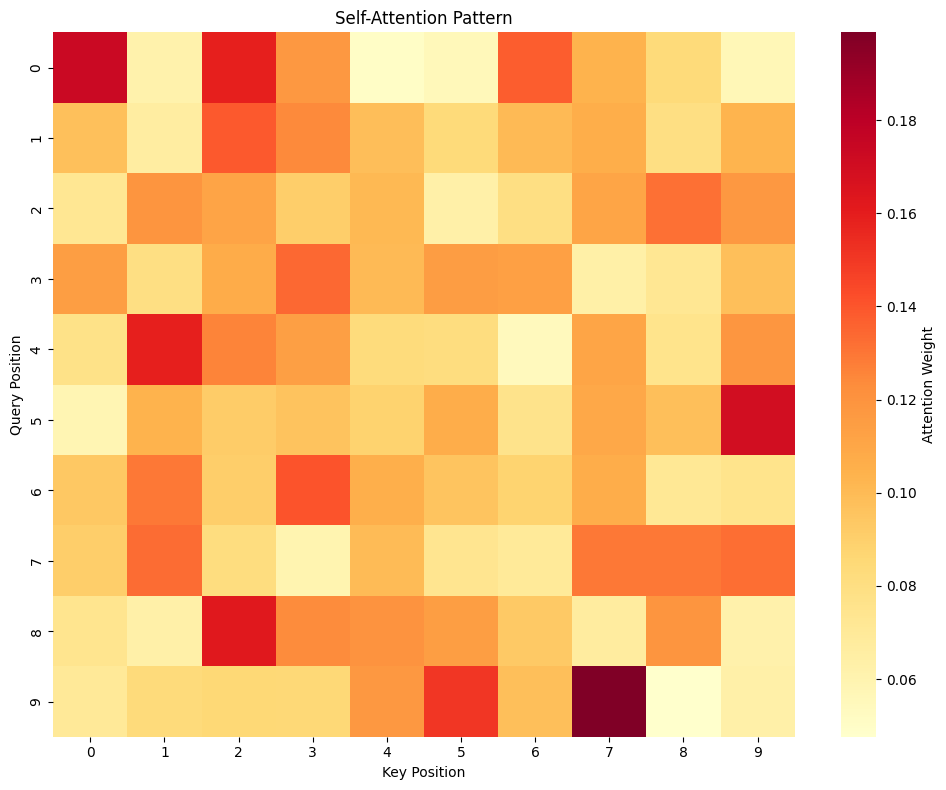

In [28]:
# Visualize attention weights
attn_matrix = weights[0].detach().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(attn_matrix, cmap='YlOrRd', cbar_kws={'label': 'Attention Weight'})
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.title('Self-Attention Pattern')
plt.tight_layout()
plt.show()

**Interpreting attention**:
- Each row shows what that position attends to
- Bright spots = high attention
- Diagonal pattern = tokens attend to themselves
- Off-diagonal = tokens attend to other positions

In real transformers (BERT, GPT), attention patterns reveal linguistic relationships, syntactic structure, and semantic dependencies.

## 8. Integrated Gradients

**Integrated Gradients** is a gradient-based attribution method that satisfies important axioms:
1. **Sensitivity**: If features differ but predictions don't, attributions are zero
2. **Implementation invariance**: Functionally equivalent models have identical attributions

### The Core Idea

Regular gradients can be noisy and misleading (gradient saturation). Integrated gradients fix this by:
1. Starting from a baseline (e.g., all zeros)
2. Gradually interpolating to the actual input
3. Integrating gradients along this path

$$\text{IntegratedGrad}_i(x) = (x_i - x'_i) \times \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x - x'))}{\partial x_i} d\alpha$$

Where $x'$ is the baseline and $x$ is our input.

Implement integrated gradients from scratch.

In [29]:
def integrated_gradients(model, input_tensor, target_class, baseline=None, steps=50):
    """Compute integrated gradients for an input.
    
    Args:
        model: PyTorch model
        input_tensor: Input to explain (requires_grad=True)
        target_class: Class to compute attributions for
        baseline: Baseline input (default: zeros)
        steps: Number of interpolation steps
    
    Returns:
        Attributions with same shape as input
    """
    if baseline is None:
        baseline = torch.zeros_like(input_tensor)
    
    # Generate interpolated inputs
    alphas = torch.linspace(0, 1, steps).to(input_tensor.device)
    
    # Compute gradients for each interpolated input
    gradients = []
    for alpha in alphas:
        interpolated = baseline + alpha * (input_tensor - baseline)
        interpolated = interpolated.detach().requires_grad_(True)  # Detach and enable grad
        
        output = model(interpolated)
        
        # Backward for target class
        model.zero_grad()
        if interpolated.grad is not None:
            interpolated.grad.zero_()
        
        output[0, target_class].backward()
        
        gradients.append(interpolated.grad.clone())
    
    # Average gradients (approximate integral)
    avg_gradients = torch.stack(gradients).mean(dim=0)
    
    # Multiply by input difference
    integrated_grad = (input_tensor - baseline) * avg_gradients
    
    return integrated_grad.detach()

print("Integrated gradients function defined")

Integrated gradients function defined


Apply integrated gradients to a MNIST image.

In [30]:
# Get a test image
test_img = test_images[img_idx:img_idx+1].to(device)
test_img.requires_grad = True

# Compute integrated gradients
attributions = integrated_gradients(
    cnn_model,
    test_img,
    target_class=pred,
    steps=50
)

print(f"Attributions shape: {attributions.shape}")

Attributions shape: torch.Size([1, 1, 28, 28])


Visualize the attributions alongside the original image.

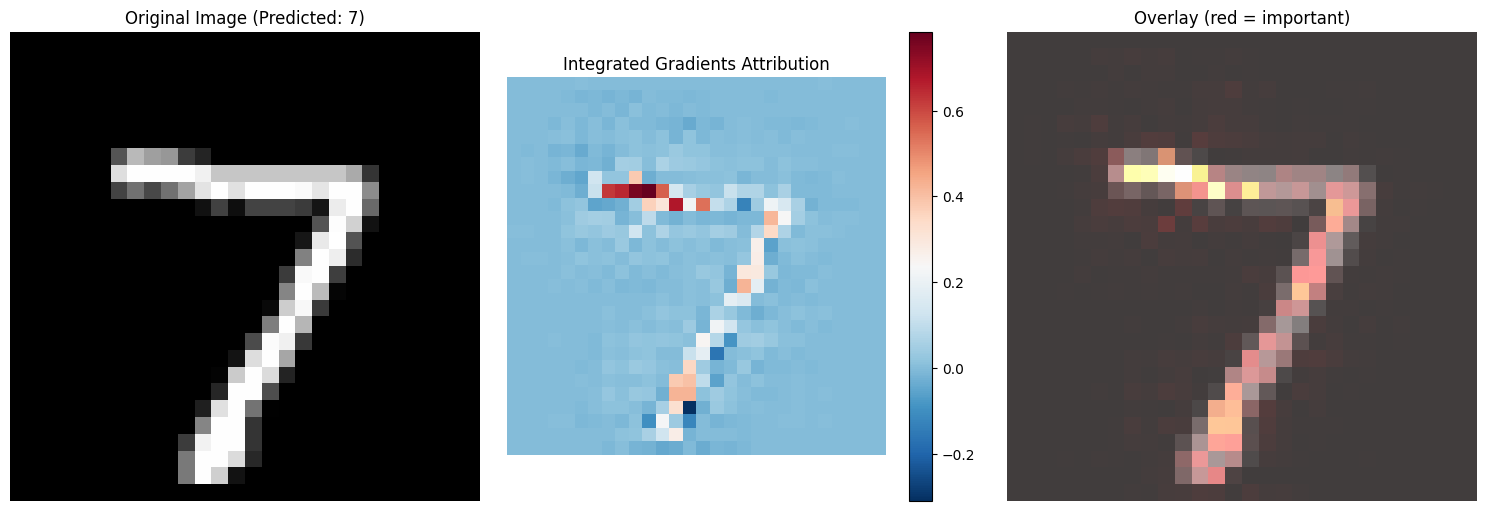

In [31]:
# Visualize
attr_np = attributions.detach().cpu().squeeze().numpy()
img_np = test_img.detach().cpu().squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'Original Image (Predicted: {pred})')
axes[0].axis('off')

# Attributions
im1 = axes[1].imshow(attr_np, cmap='RdBu_r')
axes[1].set_title('Integrated Gradients Attribution')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Overlay
axes[2].imshow(img_np, cmap='gray', alpha=0.6)
axes[2].imshow(np.abs(attr_np), cmap='hot', alpha=0.4)
axes[2].set_title('Overlay (red = important)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 8.1 Compare with Vanilla Gradients

Let's see why integrated gradients are better than simple gradients.

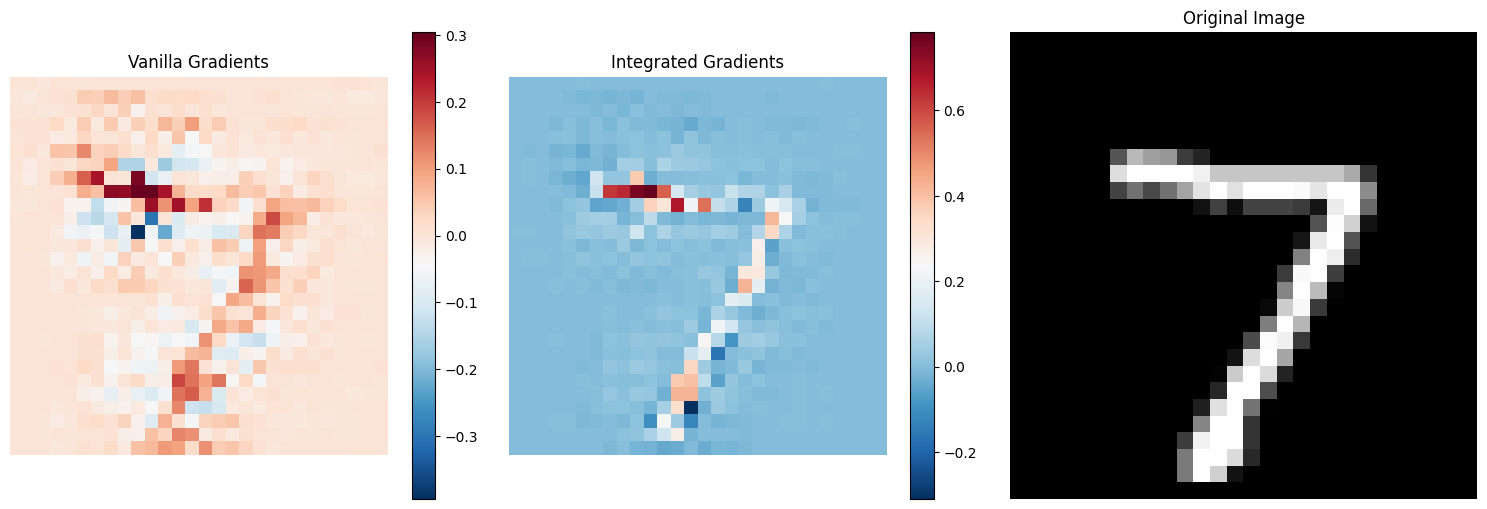

In [32]:
# Compute vanilla gradients
test_img_grad = test_images[img_idx:img_idx+1].to(device)
test_img_grad.requires_grad = True

output = cnn_model(test_img_grad)
cnn_model.zero_grad()
output[0, pred].backward()

vanilla_grad = test_img_grad.grad.detach().cpu().squeeze().numpy()

# Compare
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Vanilla gradients
im1 = axes[0].imshow(vanilla_grad, cmap='RdBu_r')
axes[0].set_title('Vanilla Gradients')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

# Integrated gradients
im2 = axes[1].imshow(attr_np, cmap='RdBu_r')
axes[1].set_title('Integrated Gradients')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

# Original for reference
axes[2].imshow(img_np, cmap='gray')
axes[2].set_title('Original Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Key observation**: Integrated gradients typically produce cleaner, more focused attributions. Vanilla gradients can be noisy because they only look at the gradient at a single point, while integrated gradients average over the entire path from baseline to input.

## 9. Activation Maximization

**Activation maximization** answers: "What input would maximally activate this neuron/class?"

Instead of analyzing existing inputs, we **generate** inputs that maximize specific activations. This reveals what the network is looking for.

### 9.1 Generate Class-Specific Images

Start from random noise and use gradient ascent to maximize the score for a target class.

In [33]:
def activation_maximization(model, target_class, steps=200, lr=0.1):
    """Generate an input that maximizes activation for a target class.
    
    Args:
        model: PyTorch model
        target_class: Class to maximize
        steps: Optimization steps
        lr: Learning rate
    
    Returns:
        Generated image
    """
    # Start from random noise
    img = torch.randn(1, 1, 28, 28).to(device)
    img.requires_grad = True
    
    optimizer = torch.optim.Adam([img], lr=lr)
    
    model.eval()
    for step in range(steps):
        optimizer.zero_grad()
        
        output = model(img)
        # Maximize the target class score
        loss = -output[0, target_class]  # Negative because we maximize
        
        # Add regularization to keep image reasonable
        reg = 0.01 * torch.norm(img)
        total_loss = loss + reg
        
        total_loss.backward()
        optimizer.step()
        
        if step % 50 == 0:
            print(f"Step {step}, Score: {output[0, target_class].item():.3f}")
    
    return img.detach()

print("Activation maximization function defined")

Activation maximization function defined


Generate images for each digit class.

In [34]:
# Generate one image per digit
generated_images = []

for digit in range(10):
    print(f"\nGenerating image for digit {digit}:")
    img = activation_maximization(cnn_model, digit, steps=200, lr=0.1)
    generated_images.append(img)

print("\nGeneration complete!")


Generating image for digit 0:
Step 0, Score: -1.873
Step 50, Score: 60.256


Step 100, Score: 131.492


Step 150, Score: 203.656

Generating image for digit 1:
Step 0, Score: -0.289


Step 50, Score: 59.115


Step 100, Score: 139.974
Step 150, Score: 219.071



Generating image for digit 2:
Step 0, Score: -0.526


Step 50, Score: 119.028
Step 100, Score: 246.554


Step 150, Score: 378.542



Generating image for digit 3:
Step 0, Score: 3.546
Step 50, Score: 132.329


Step 100, Score: 267.118
Step 150, Score: 401.662

Generating image for digit 4:
Step 0, Score: -1.875


Step 50, Score: 83.780
Step 100, Score: 191.588


Step 150, Score: 303.613

Generating image for digit 5:
Step 0, Score: 4.091


Step 50, Score: 135.688
Step 100, Score: 269.810
Step 150, Score: 403.119



Generating image for digit 6:
Step 0, Score: -2.119
Step 50, Score: 82.602
Step 100, Score: 171.367


Step 150, Score: 263.939

Generating image for digit 7:
Step 0, Score: 0.187
Step 50, Score: 93.457


Step 100, Score: 190.071
Step 150, Score: 287.685

Generating image for digit 8:
Step 0, Score: -0.552


Step 50, Score: 80.365
Step 100, Score: 168.243
Step 150, Score: 259.313



Generating image for digit 9:
Step 0, Score: -1.572
Step 50, Score: 76.644
Step 100, Score: 166.217


Step 150, Score: 256.148

Generation complete!


Visualize the generated images.

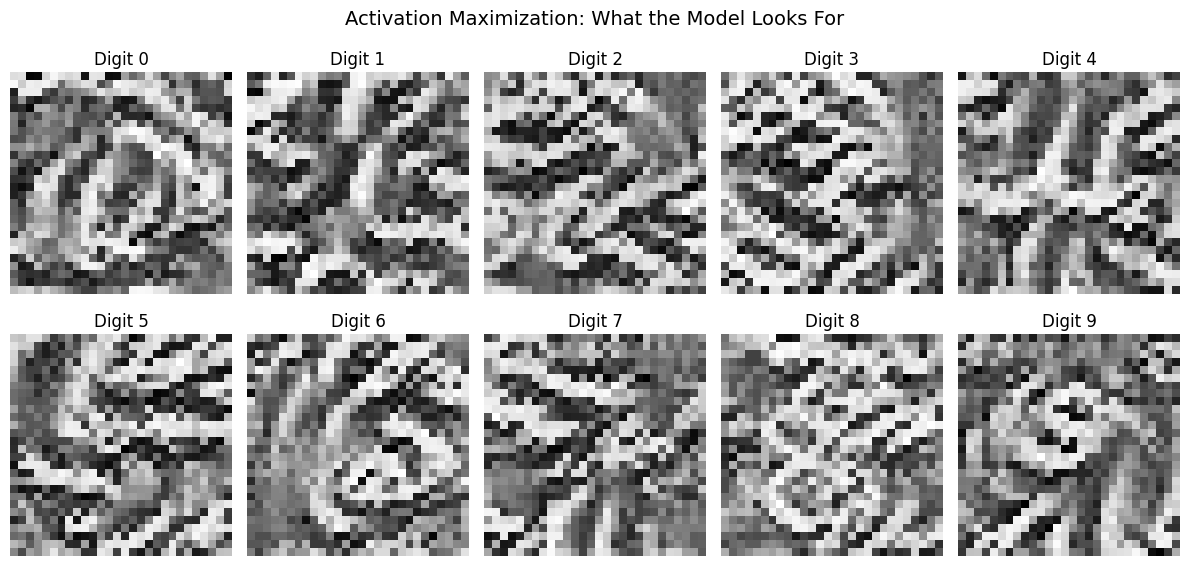

In [35]:
# Visualize all generated images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.flatten()

for i, img in enumerate(generated_images):
    img_np = img.cpu().squeeze().numpy()
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f'Digit {i}')
    axes[i].axis('off')

plt.suptitle('Activation Maximization: What the Model Looks For', fontsize=14)
plt.tight_layout()
plt.show()

**Interpreting the results**: These generated images show the **prototypical patterns** the model associates with each class. They might not look exactly like real digits, but they highlight the features the model finds most distinctive.

## 10. Comparing Methods

Different interpretability methods reveal different insights. Let's apply multiple methods to the same example and compare.

### 10.1 Multi-Method Comparison on One Image

We'll apply LIME, integrated gradients, and vanilla gradients to the same digit.

In [36]:
# Select an image
comparison_idx = 5
comp_img = test_images[comparison_idx:comparison_idx+1].to(device)
comp_label = test_labels[comparison_idx].item()

# Get prediction
cnn_model.eval()
with torch.no_grad():
    comp_output = cnn_model(comp_img)
    comp_pred = comp_output.argmax(dim=1).item()
    comp_conf = F.softmax(comp_output, dim=1)[0, comp_pred].item()

print(f"True: {comp_label}, Predicted: {comp_pred}, Confidence: {comp_conf:.3f}")

True: 1, Predicted: 1, Confidence: 1.000


Compute explanations with each method.

In [37]:
# 1. Vanilla gradients
comp_img_grad = comp_img.clone()
comp_img_grad.requires_grad = True
output = cnn_model(comp_img_grad)
cnn_model.zero_grad()
output[0, comp_pred].backward()
vanilla = comp_img_grad.grad.detach().cpu().squeeze().numpy()

# 2. Integrated gradients
comp_img_ig = comp_img.clone()
comp_img_ig.requires_grad = True
ig_attr = integrated_gradients(cnn_model, comp_img_ig, comp_pred, steps=50)
ig = ig_attr.detach().cpu().squeeze().numpy()

# 3. LIME
comp_img_lime = comp_img.cpu().squeeze().numpy()[..., np.newaxis]
lime_exp = image_explainer.explain_instance(
    comp_img_lime,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000,
    segmentation_fn=segment_grayscale  # Use our custom grayscale segmentation
)
_, lime_mask = lime_exp.get_image_and_mask(
    comp_pred,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

print("All explanations computed")

  0%|          | 0/1000 [00:00<?, ?it/s]

All explanations computed


Visualize all methods side by side.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087585].


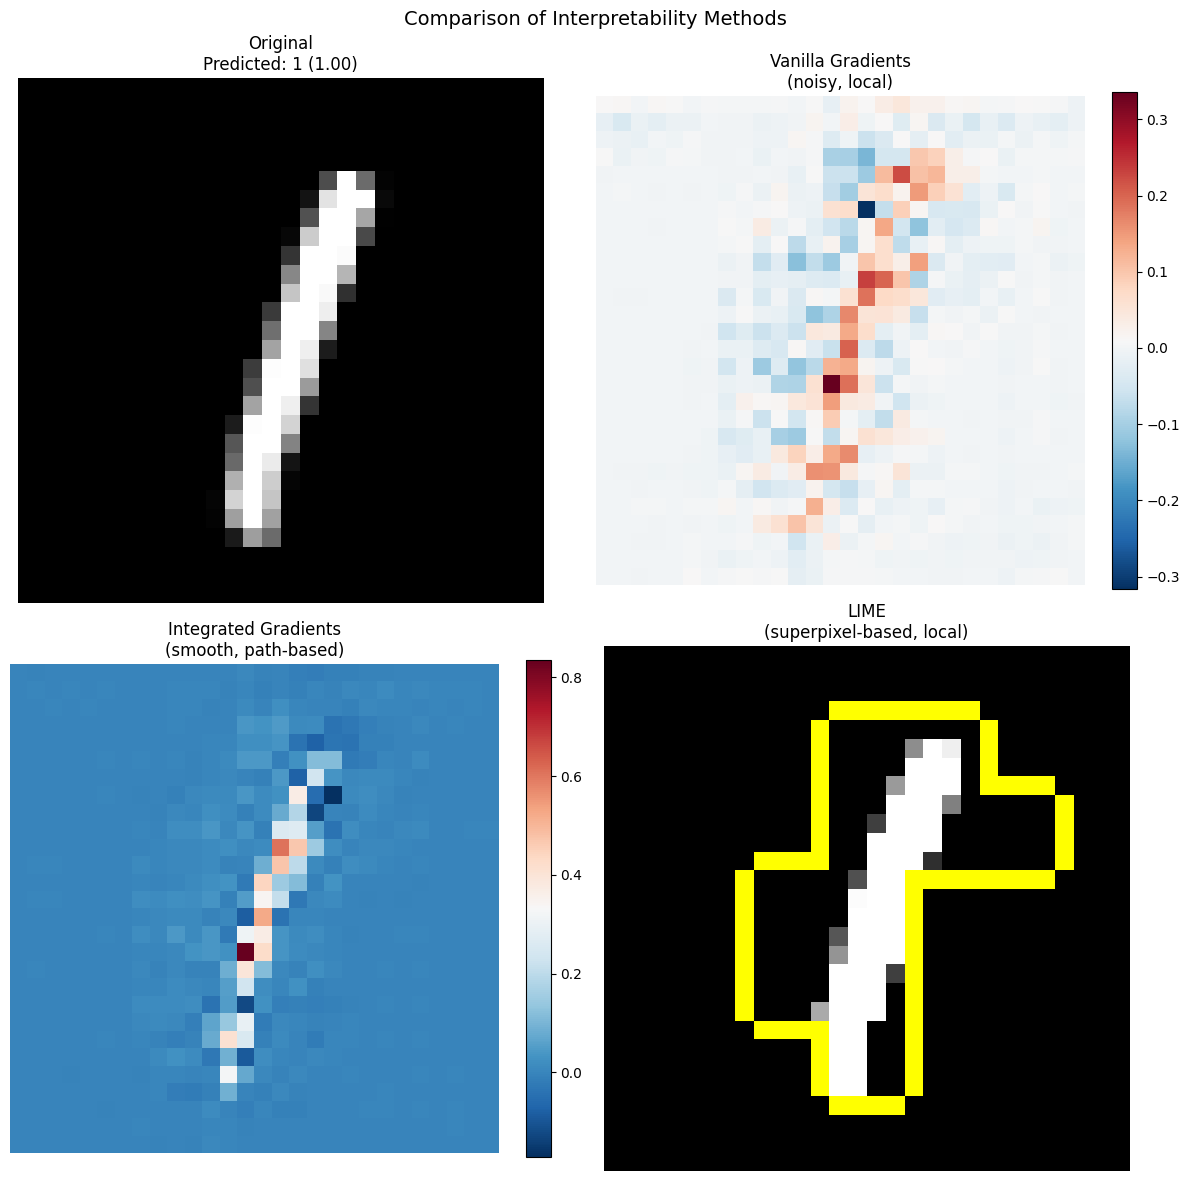

In [38]:
# Create comparison visualization
img_display = comp_img.cpu().squeeze().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Original
axes[0, 0].imshow(img_display, cmap='gray')
axes[0, 0].set_title(f'Original\nPredicted: {comp_pred} ({comp_conf:.2f})', fontsize=12)
axes[0, 0].axis('off')

# Vanilla gradients
im1 = axes[0, 1].imshow(vanilla, cmap='RdBu_r')
axes[0, 1].set_title('Vanilla Gradients\n(noisy, local)', fontsize=12)
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# Integrated gradients
im2 = axes[1, 0].imshow(ig, cmap='RdBu_r')
axes[1, 0].set_title('Integrated Gradients\n(smooth, path-based)', fontsize=12)
axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

# LIME
axes[1, 1].imshow(mark_boundaries(comp_img_lime.squeeze(), lime_mask))
axes[1, 1].set_title('LIME\n(superpixel-based, local)', fontsize=12)
axes[1, 1].axis('off')

plt.suptitle('Comparison of Interpretability Methods', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## 11. Practical Guidelines

### When to Use Each Method

Now that we've explored various methods, let's understand when each is most appropriate.

### 11.1 Method Comparison Summary

Create a comparison table showing properties of each method.

In [39]:
import pandas as pd

# Create comparison dataframe
comparison_data = {
    'Method': [
        'Feature Importance',
        'Permutation Importance',
        'LIME',
        'SHAP',
        'Attention Visualization',
        'Integrated Gradients',
        'Activation Maximization'
    ],
    'Type': [
        'Global',
        'Global',
        'Local',
        'Both',
        'Local',
        'Local',
        'Global'
    ],
    'Model-Agnostic': [
        'No',
        'Yes',
        'Yes',
        'Yes',
        'No',
        'No',
        'No'
    ],
    'Speed': [
        'Fast',
        'Slow',
        'Medium',
        'Medium',
        'Fast',
        'Medium',
        'Slow'
    ],
    'Best For': [
        'Tree models, quick insights',
        'Any model, reliable ranking',
        'Individual predictions',
        'Rigorous explanations',
        'Transformers, sequences',
        'Pixel-level attribution',
        'Understanding learned features'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                 Method   Type Model-Agnostic  Speed                       Best For
     Feature Importance Global             No   Fast    Tree models, quick insights
 Permutation Importance Global            Yes   Slow    Any model, reliable ranking
                   LIME  Local            Yes Medium         Individual predictions
                   SHAP   Both            Yes Medium          Rigorous explanations
Attention Visualization  Local             No   Fast        Transformers, sequences
   Integrated Gradients  Local             No Medium        Pixel-level attribution
Activation Maximization Global             No   Slow Understanding learned features


### 11.2 Decision Tree for Choosing a Method

Here's a practical guide for selecting an interpretability method:

**Start with these questions:**

1. **Do you need global or local explanations?**
   - Global (overall behavior) → Feature importance, SHAP summary, activation maximization
   - Local (specific predictions) → LIME, SHAP force plots, integrated gradients

2. **What type of model do you have?**
   - Tree-based → Use built-in feature importance, fast and reliable
   - Neural network with attention → Visualize attention weights first
   - Any other model → Use model-agnostic methods (LIME, SHAP, permutation)

3. **What type of data?**
   - Tabular → SHAP, permutation importance
   - Images → Integrated gradients, LIME, Grad-CAM
   - Text/sequences → Attention visualization, LIME

4. **How much time do you have?**
   - Quick check → Built-in importance, attention weights
   - Thorough analysis → SHAP, integrated gradients
   - Research/publication → Multiple methods for robustness

### 11.3 Limitations and Caveats

**All interpretability methods have limitations:**

1. **LIME**:
   - Unstable: different runs can give different results
   - Depends on how you perturb data
   - Linear approximation may not capture complex decision boundaries

2. **SHAP**:
   - Slow for large models/datasets
   - KernelSHAP is an approximation (TreeSHAP is exact)
   - Can be counterintuitive for highly correlated features

3. **Integrated Gradients**:
   - Requires choosing a baseline (can affect results)
   - Only works for differentiable models
   - Computational cost scales with number of steps

4. **Attention Weights**:
   - Attention ≠ explanation (controversial in research)
   - Multiple heads can be hard to interpret
   - Doesn't explain what happens after attention

5. **Activation Maximization**:
   - Generated images can be unnatural
   - Requires careful regularization
   - May not reflect real data distribution

## 12. Key Takeaways

Let's consolidate what we've learned about model interpretability.

### Core Concepts

1. **Interpretability vs Explainability**:
   - **Interpretability**: Understanding how the model works internally
   - **Explainability**: Understanding why a specific decision was made
   - We need both for trustworthy AI

2. **Global vs Local**:
   - **Global**: Overall model behavior (feature importance, SHAP summary)
   - **Local**: Individual predictions (LIME, SHAP force plots)
   - Different questions require different scopes

3. **Model-Agnostic vs Model-Specific**:
   - **Agnostic**: Work with any model (LIME, SHAP, permutation)
   - **Specific**: Leverage model structure (attention, gradients)
   - Trade-off between generality and insight

### Practical Insights

1. **No perfect method**: Each reveals different aspects - use multiple methods
2. **Context matters**: Choose methods based on your use case (debugging, compliance, research)
3. **Sanity check**: Explanations should align with domain knowledge
4. **Be skeptical**: All methods make assumptions - understand their limitations

### When Interpretability Really Matters

- **High-stakes decisions**: Healthcare, finance, criminal justice
- **Debugging**: Finding why models fail on edge cases
- **Trust building**: Showing stakeholders the model is reasonable
- **Fairness audits**: Detecting and removing biased features
- **Regulatory compliance**: Explaining automated decisions (GDPR, etc.)
- **Scientific discovery**: Understanding what patterns the model found

### The Bottom Line

**Interpretability is not a luxury - it's a necessity for responsible AI.** As models become more powerful and deployed in critical domains, understanding their decisions becomes increasingly important.

Start simple (feature importance), go deeper when needed (SHAP, integrated gradients), and always validate explanations against domain expertise.